# 판매자 지각 후 만회(정시 도착)해도 평점이 낮은 이유 분석

## 문제 제기 (NG 분석에서 발견)

| 그룹 | 정의 | 평균 평점 | n |
|------|------|---------|---|
| **A** 판매자OK + 정시 도착 | `is_seller_late=0` & `is_late=0` | **4.22점** | 95,965 |
| **B** 판매자지각 + 정시 도착(만회) | `is_seller_late=1` & `is_late=0` | **3.90점** | 3,337 |
| 차이 | | **-0.32점** (p<0.001) | |

**두 그룹 모두 최종 배송은 예상일 안에 도착했는데 왜 평점이 다른가?**

## 가설 트리
```
판매자 지각 후 만회
  ├─ [H1] 실제 배송일 자체가 더 길다  (delivery_days ↑)
  ├─ [H2] 상품 특성이 다르다         (카테고리, 무게, 가격)
  ├─ [H3] 지역 구성이 다르다         (먼 지역 배송 비중)
  └─ [H4] estimated_window가 더 길다 (기다림 자체에 대한 불만)
```

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

ROOT = Path('../../').resolve()
df_raw = pd.read_csv(ROOT / 'data/processed/olist_order_item_level.csv')

for c in ['order_delivered_customer_date', 'order_estimated_delivery_date',
          'order_delivered_carrier_date', 'shipping_limit_date']:
    df_raw[c] = pd.to_datetime(df_raw[c], errors='coerce')

d = df_raw[
    (df_raw['order_status'] == 'delivered') &
    (df_raw['anomaly_flag'] == 0) &
    df_raw['review_score_mean'].notna()
].copy()

d['is_late']          = d['order_delivered_customer_date'] > d['order_estimated_delivery_date']
d['seller_delay']     = (d['order_delivered_carrier_date'] - d['shipping_limit_date']).dt.days
d['is_seller_late']   = d['seller_delay'] > 0
d['carrier_days']     = (d['order_delivered_customer_date'] - d['order_delivered_carrier_date']).dt.days
d['delivery_days']    = (d['order_delivered_customer_date'] - pd.to_datetime(d['order_purchase_timestamp'])).dt.days
d['estimated_window'] = (d['order_estimated_delivery_date'] - pd.to_datetime(d['order_purchase_timestamp'])).dt.days
d['buffer_days']      = d['estimated_window'] - d['delivery_days']

g_AA = d[~d['is_seller_late'] & ~d['is_late']].copy()
g_BA = d[ d['is_seller_late'] & ~d['is_late']].copy()
g_AB = d[~d['is_seller_late'] &  d['is_late']].copy()
g_BB = d[ d['is_seller_late'] &  d['is_late']].copy()

print('그룹별 기본 통계')
for name, grp in [('A: 판매자OK+정시', g_AA), ('B: 판매자지각+정시(만회)', g_BA),
                   ('C: 판매자OK+최종지연', g_AB), ('D: 판매자지각+최종지연', g_BB)]:
    print(f'  {name:25s}: n={len(grp):6,}  평점={grp["review_score_mean"].mean():.4f}')

t, p = stats.ttest_ind(g_AA['review_score_mean'], g_BA['review_score_mean'])
print(f'\nA vs B 평점 차이: {g_AA["review_score_mean"].mean()-g_BA["review_score_mean"].mean():.4f}점  (t={t:.2f}, p={p:.2e})')

그룹별 기본 통계
  A: 판매자OK+정시              : n=95,965  평점=4.2225
  B: 판매자지각+정시(만회)          : n= 3,337  평점=3.9016
  C: 판매자OK+최종지연            : n= 6,767  평점=2.5847
  D: 판매자지각+최종지연            : n= 1,717  평점=2.3963

A vs B 평점 차이: 0.3209점  (t=14.82, p=1.17e-49)


---
## 1단계 — 그룹 간 주요 피처 차이 전체 파악

---
## 전제 인사이트 — "약속(estimated_delivery_date)을 지키면 평점이 관리된다"

NG EDA에서 먼저 확인된 사실: 고객 예상 배송일 기준 **도착 시점에 따라 평점이 구조적으로 달라진다.**

```
조기 배송(7일+)  4.23점  ┐
조기 배송(4~7일) 4.13점  │ 약속 지킨 구간 → 4점대 유지
조기 배송(2~3일) 4.09점  │
정시(0일)        3.68점  ┘ ← 약속의 마지노선
────────────────────────── 이 선 아래부터 급락
1~3일 지연       2.87점
4~7일 지연       2.09점
7일+  지연       1.70점
```

**→ 판매자가 지각해서 배송이 18일 걸려도, 예상일 안에만 들어오면(B그룹: 3.90) 약속이 깨지는 것(C그룹: 2.58)보다 훨씬 낫다.**  
**→ 따라서 "A(4.22) vs B(3.90)"의 0.32점 차이는, "약속이 깨지는 것(0.32점 차이)" 보다 훨씬 작은 문제다.**

이 섹션은 위 전제 위에서 **왜 같은 '약속 지킴' 그룹 안에서도 차이가 생기는지** 를 분석한다.

C:\Users\sun94\AppData\Local\Temp\ipykernel_20224\3994148805.py:86: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\team-oldest-olist-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


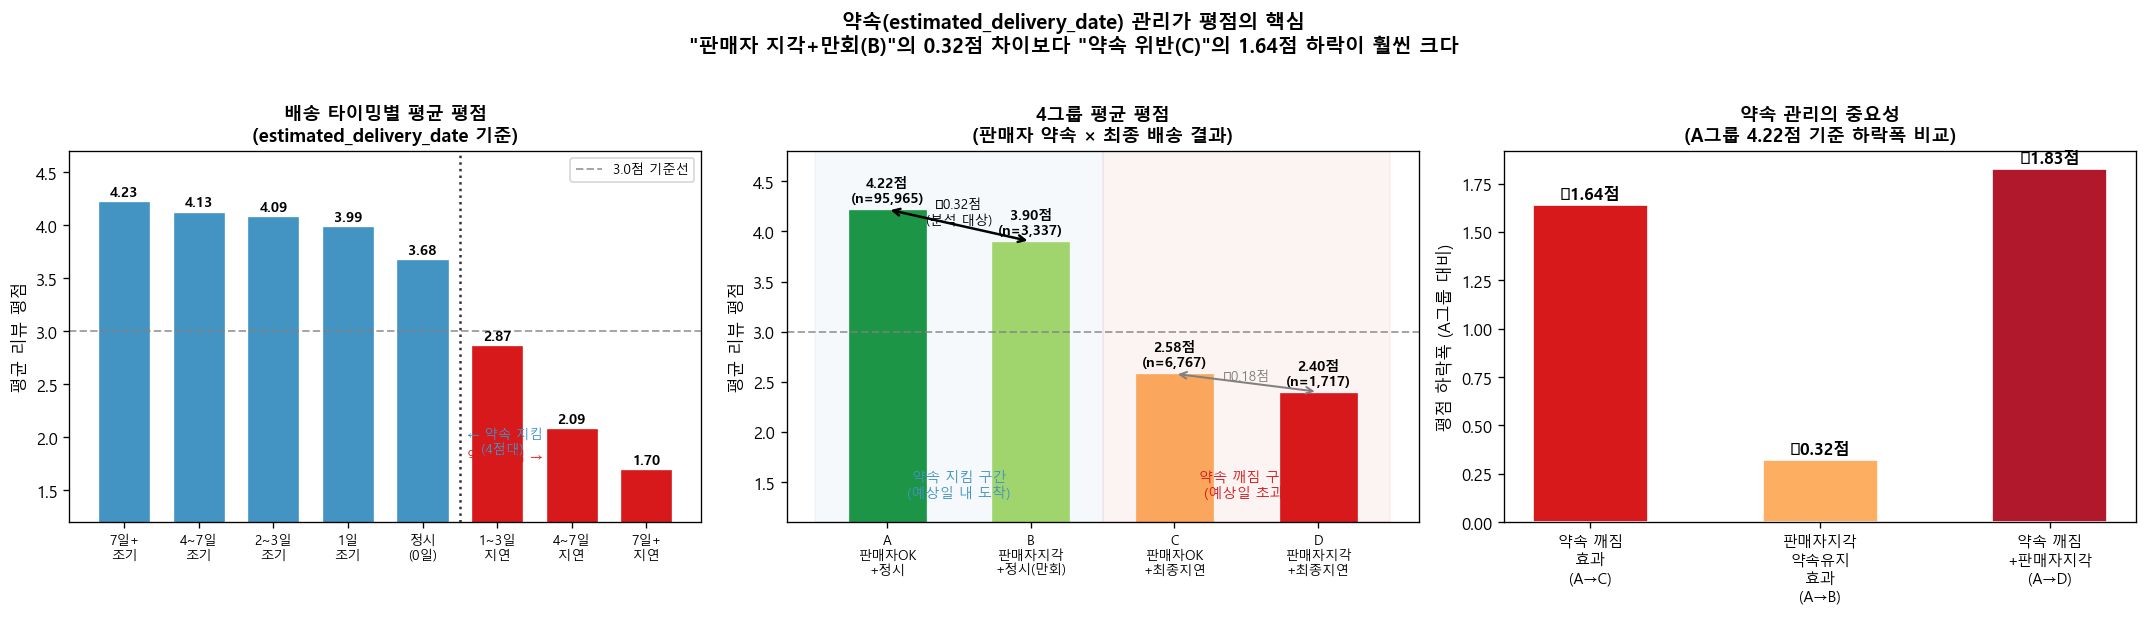

In [11]:
# 약속 지킴 구조 전체 시각화 — 4그룹 + 지연 타이밍 분포

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 왼쪽: delay_days 구간별 평균 평점 (약속 기준선 시각화)
ax = axes[0]
timing_data = {
    '7일+\n조기':  (4.23, 86858),
    '4~7일\n조기': (4.13, 10658),
    '2~3일\n조기': (4.09,  3327),
    '1일\n조기':   (3.99,  1436),
    '정시\n(0일)': (3.68,   932),
    '1~3일\n지연': (2.87,  1156),
    '4~7일\n지연': (2.09,  1943),
    '7일+\n지연':  (1.70,  3052),
}
labels_t = list(timing_data.keys())
scores_t = [v[0] for v in timing_data.values()]
bar_colors_t = ['#4393c3' if '조기' in l or '정시' in l else '#d7191c' for l in labels_t]

bars = ax.bar(labels_t, scores_t, color=bar_colors_t, edgecolor='white', linewidth=0.8, width=0.7)
for bar, score in zip(bars, scores_t):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{score:.2f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.axhline(3.0, color='gray', lw=1.2, ls='--', alpha=0.7, label='3.0점 기준선')
ax.axvline(4.5, color='black', lw=1.5, ls=':', alpha=0.8)
ax.text(4.6, 1.85, '← 약속 지킴\n   (4점대)', fontsize=8, color='#4393c3')
ax.text(4.6, 1.65, '약속 깨짐 →\n  (2점대)', fontsize=8, color='#d7191c')
ax.set_ylabel('평균 리뷰 평점', fontsize=10)
ax.set_ylim(1.2, 4.7)
ax.set_title('배송 타이밍별 평균 평점\n(estimated_delivery_date 기준)', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', labelsize=8)
ax.legend(fontsize=8)

# ── 가운데: 4그룹 평점 + 크기 버블
ax = axes[1]
groups = ['A\n판매자OK\n+정시', 'B\n판매자지각\n+정시(만회)', 'C\n판매자OK\n+최종지연', 'D\n판매자지각\n+최종지연']
scores4 = [4.2225, 3.9016, 2.5847, 2.3963]
sizes4  = [95965,   3337,   6767,   1717]
colors4 = ['#1a9641', '#a6d96a', '#fdae61', '#d7191c']

bars4 = ax.bar(groups, scores4, color=colors4, edgecolor='white', linewidth=0.8, width=0.55)
for bar, s, n in zip(bars4, scores4, sizes4):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
            f'{s:.2f}점\n(n={n:,})', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# 약속 지킴 / 깨짐 구분선
ax.axhline(3.0, color='gray', lw=1.2, ls='--', alpha=0.7)
ax.axvspan(-0.5, 1.5, alpha=0.05, color='#4393c3')
ax.axvspan(1.5, 3.5, alpha=0.05, color='#d7191c')
ax.text(0.5,  1.35, '약속 지킴 구간\n(예상일 내 도착)', ha='center', fontsize=8.5, color='#4393c3')
ax.text(2.5,  1.35, '약속 깨짐 구간\n(예상일 초과)',    ha='center', fontsize=8.5, color='#d7191c')

# A-B 차이, C-D 차이 브레이스
ax.annotate('', xy=(1, 3.90), xytext=(0, 4.22),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(0.5, 4.08, '−0.32점\n(분석 대상)', ha='center', fontsize=8, color='black')
ax.annotate('', xy=(3, 2.40), xytext=(2, 2.58),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
ax.text(2.5, 2.52, '−0.18점', ha='center', fontsize=8, color='gray')

ax.set_ylabel('평균 리뷰 평점', fontsize=10)
ax.set_ylim(1.1, 4.8)
ax.set_title('4그룹 평균 평점\n(판매자 약속 × 최종 배송 결과)', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', labelsize=8)

# ── 오른쪽: 핵심 메시지 비교 — 약속 지킴/깨짐 효과 vs A-B 차이
ax = axes[2]
categories = ['약속 깨짐\n효과\n(A→C)', '판매자지각\n약속유지\n효과\n(A→B)', '약속 깨짐\n+판매자지각\n(A→D)']
gaps       = [4.2225-2.5847, 4.2225-3.9016, 4.2225-2.3963]
colors_g   = ['#d7191c', '#fdae61', '#b2182b']

bars_g = ax.bar(categories, gaps, color=colors_g, edgecolor='white', width=0.5)
for bar, gap in zip(bars_g, gaps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'−{gap:.2f}점', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('평점 하락폭 (A그룹 대비)', fontsize=10)
ax.set_title('약속 관리의 중요성\n(A그룹 4.22점 기준 하락폭 비교)', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', labelsize=9)

plt.suptitle('약속(estimated_delivery_date) 관리가 평점의 핵심\n'
             '"판매자 지각+만회(B)"의 0.32점 차이보다 "약속 위반(C)"의 1.64점 하락이 훨씬 크다',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

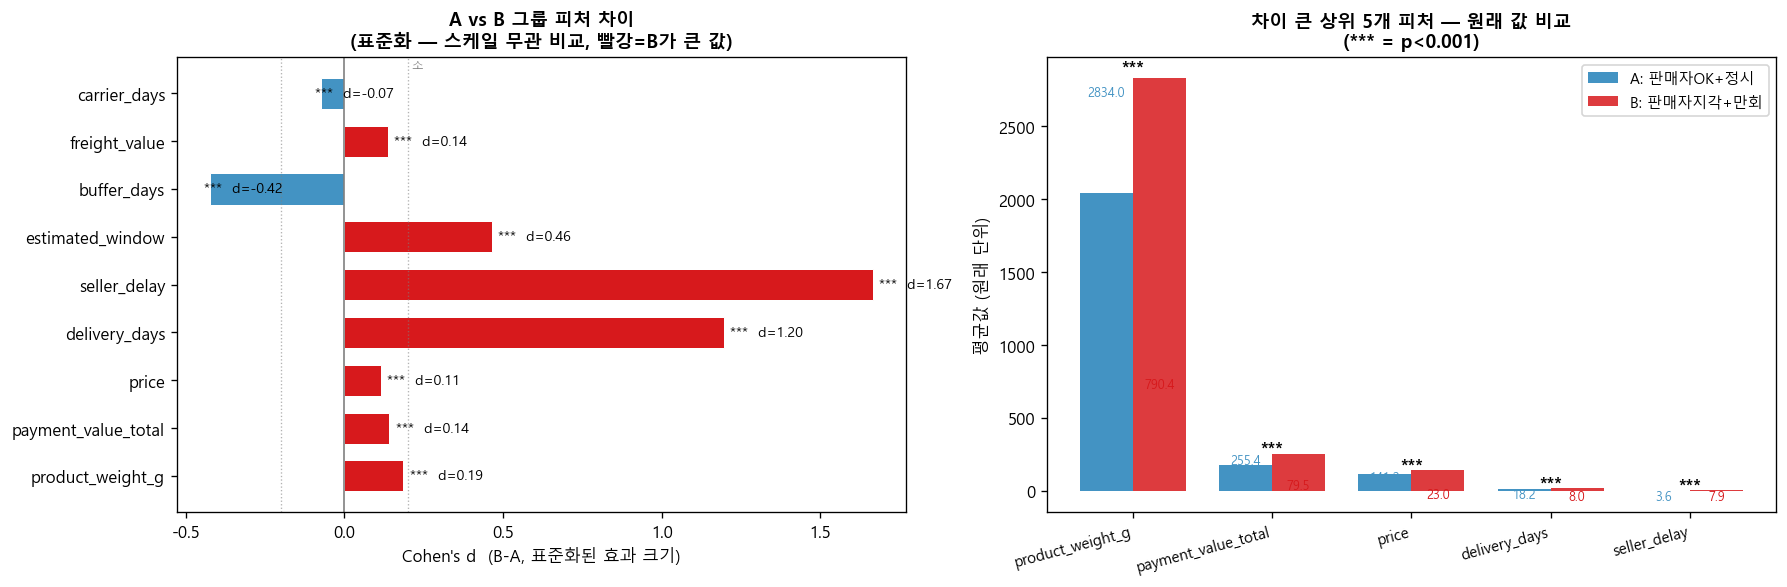


▶ 전체 피처 비교표
  product_weight_g             A= 2043.62  B= 2834.04  diff= +790.41  ***
  payment_value_total          A=  175.95  B=  255.42  diff=  +79.47  ***
  price                        A=  118.21  B=  141.25  diff=  +23.04  ***
  delivery_days                A=   10.16  B=   18.18  diff=   +8.02  ***
  seller_delay                 A=   -4.33  B=    3.55  diff=   +7.88  ***
  estimated_window             A=   23.45  B=   28.08  diff=   +4.63  ***
  buffer_days                  A=   13.29  B=    9.90  diff=   -3.39  ***
  freight_value                A=   19.68  B=   22.06  diff=   +2.38  ***
  carrier_days                 A=    7.38  B=    7.00  diff=   -0.38  ***

  ※ payment_installments_max 제외 (p=0.062, 통계적으로 유의하지 않음)


In [12]:
# payment_installments_max 제외 (p=0.062, 유의하지 않음)
num_features = ['delivery_days', 'seller_delay', 'carrier_days', 'estimated_window',
                'buffer_days', 'price', 'freight_value', 'payment_value_total',
                'product_weight_g']

compare = []
for f in num_features:
    if f not in d.columns:
        continue
    a_vals = g_AA[f].dropna()
    b_vals = g_BA[f].dropna()
    t_stat, p_val = stats.ttest_ind(a_vals, b_vals)
    compare.append({
        'feature':    f,
        'A(OK+정시)': a_vals.mean(),
        'B(지각+만회)': b_vals.mean(),
        'diff(B-A)':  b_vals.mean() - a_vals.mean(),
        'p_value':    p_val,
    })

cmp_df = pd.DataFrame(compare).sort_values('diff(B-A)', key=abs, ascending=False)

# 스케일이 달라 원래 값 비교가 어렵기 때문에 → Z-score로 표준화한 차이를 표시
from scipy.stats import zscore as sp_zscore

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── 왼쪽: 표준화된 차이(Cohen's d 방식) — 스케일 무관 비교
ax = axes[0]
cohens_d = []
for row in cmp_df.itertuples():
    f = row.feature
    a_v = g_AA[f].dropna()
    b_v = g_BA[f].dropna()
    pooled_std = np.sqrt((a_v.std()**2 + b_v.std()**2) / 2)
    d_val = (b_v.mean() - a_v.mean()) / pooled_std if pooled_std > 0 else 0
    cohens_d.append(d_val)

bar_colors = ['#d7191c' if v > 0 else '#4393c3' for v in cohens_d]
bars = ax.barh(cmp_df['feature'], cohens_d, color=bar_colors,
               edgecolor='white', linewidth=0.6, height=0.65)
ax.axvline(0, color='gray', lw=1)

for bar, val, row in zip(bars, cohens_d, cmp_df.itertuples()):
    sig = '***' if row.p_value < 0.001 else '**' if row.p_value < 0.01 else '*' if row.p_value < 0.05 else 'ns'
    xpos = val + 0.02 if val >= 0 else val - 0.02
    ha   = 'left'  if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{sig}  d={val:.2f}', va='center', fontsize=8.5)

ax.set_xlabel("Cohen's d  (B-A, 표준화된 효과 크기)", fontsize=10)
ax.set_title("A vs B 그룹 피처 차이\n(표준화 — 스케일 무관 비교, 빨강=B가 큰 값)", fontsize=11, fontweight='bold')
ax.axvline(0.2,  color='gray', lw=0.8, ls=':', alpha=0.6)
ax.axvline(-0.2, color='gray', lw=0.8, ls=':', alpha=0.6)
ax.text(0.21, len(cmp_df)-0.5, '소', fontsize=7, color='gray')

# ── 오른쪽: 원래 평균값 비교 (상위 5개만)
ax = axes[1]
top5 = cmp_df.head(5)
x = np.arange(len(top5))
w = 0.38
b1 = ax.bar(x - w/2, top5['A(OK+정시)'],   width=w, color='#4393c3', label='A: 판매자OK+정시')
b2 = ax.bar(x + w/2, top5['B(지각+만회)'], width=w, color='#d7191c', label='B: 판매자지각+만회', alpha=0.85)

for xi, row in zip(x, top5.itertuples()):
    sig = '***' if row.p_value < 0.001 else '**' if row.p_value < 0.01 else '*'
    ax.text(xi, max(row._3, row._4) * 1.015, sig, ha='center', fontsize=10, color='black', fontweight='bold')
    ax.text(xi - w/2, row._3 * 0.98, f'{row._3:.1f}', ha='center', va='top', fontsize=7.5, color='#4393c3')
    ax.text(xi + w/2, row._4 * 0.98, f'{row._4:.1f}', ha='center', va='top', fontsize=7.5, color='#d7191c')

ax.set_xticks(x)
ax.set_xticklabels(top5['feature'], rotation=15, ha='right', fontsize=9)
ax.set_ylabel('평균값 (원래 단위)', fontsize=10)
ax.set_title('차이 큰 상위 5개 피처 — 원래 값 비교\n(*** = p<0.001)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('\n▶ 전체 피처 비교표')
for _, row in cmp_df.iterrows():
    sig = '***' if row['p_value'] < 0.001 else '**' if row['p_value'] < 0.01 else '*' if row['p_value'] < 0.05 else 'ns'
    print(f"  {row['feature']:28s} A={row['A(OK+정시)']:8.2f}  B={row['B(지각+만회)']:8.2f}  diff={row['diff(B-A)']:+8.2f}  {sig}")
print('\n  ※ payment_installments_max 제외 (p=0.062, 통계적으로 유의하지 않음)')

---
## [H1] 실제 배송일(delivery_days)이 더 길다 — 주요 원인 검증

---
## [확인] 정시 도착이어도 판매자 지각 케이스는 배송일이 긴가?

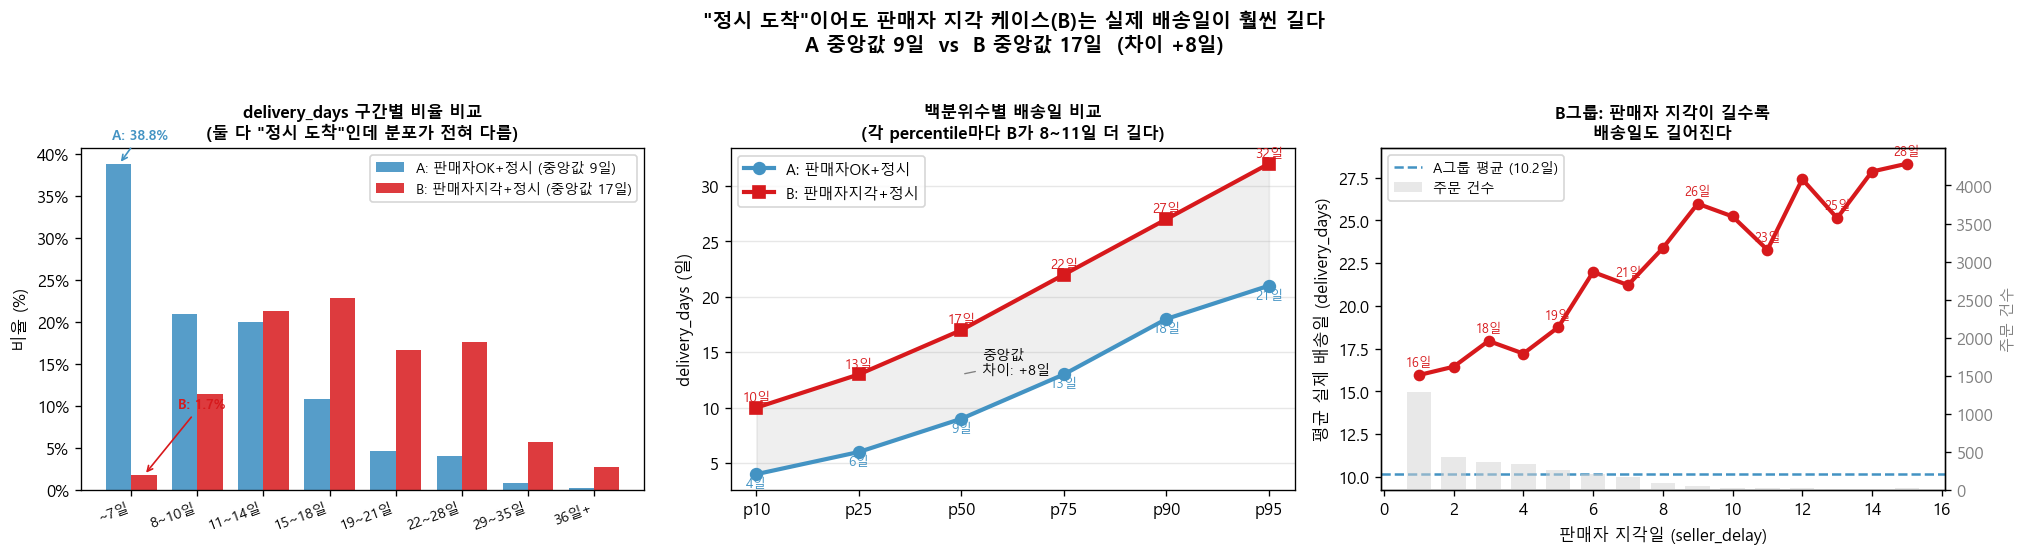

▶ 백분위수별 delivery_days 비교
              A(OK+정시)      B(지각+정시)       B-A
  p10   :           4일          10일      +6일
  p25   :           6일          13일      +7일
  p50   :           9일          17일      +8일
  p75   :          13일          22일      +9일
  p90   :          18일          27일      +9일
  p95   :          21일          32일     +11일

  A 7일 이하 비율: 38.8%
  B 7일 이하 비율: 1.7%

  → B그룹은 "정시 도착"이어도 고객이 평균 18.2일을 기다린 것
  → A그룹의 10.2일보다 8.0일 더 긴 대기


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# ── 왼쪽: delivery_days 구간별 비율 누적 비교
ax = axes[0]
bins_d = [0, 7, 10, 14, 18, 21, 28, 35, 999]
lbls_d = ['~7일', '8~10일', '11~14일', '15~18일', '19~21일', '22~28일', '29~35일', '36일+']

aa_b = pd.cut(g_AA['delivery_days'], bins=bins_d, labels=lbls_d).value_counts(normalize=True).reindex(lbls_d) * 100
ba_b = pd.cut(g_BA['delivery_days'], bins=bins_d, labels=lbls_d).value_counts(normalize=True).reindex(lbls_d) * 100

x = np.arange(len(lbls_d))
w = 0.38
b1 = ax.bar(x - w/2, aa_b.values, width=w, color='#4393c3', label=f'A: 판매자OK+정시 (중앙값 {g_AA["delivery_days"].median():.0f}일)', alpha=0.9)
b2 = ax.bar(x + w/2, ba_b.values, width=w, color='#d7191c', label=f'B: 판매자지각+정시 (중앙값 {g_BA["delivery_days"].median():.0f}일)', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(lbls_d, rotation=20, ha='right', fontsize=8.5)
ax.set_ylabel('비율 (%)', fontsize=10)
ax.set_title('delivery_days 구간별 비율 비교\n(둘 다 "정시 도착"인데 분포가 전혀 다름)', fontsize=10, fontweight='bold')
ax.legend(fontsize=8.5)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# A는 ~7일에 38.8%, B는 1.7%만 강조
ax.annotate('A: 38.8%', xy=(0 - w/2, aa_b.iloc[0]), xytext=(-0.3, aa_b.iloc[0] + 3),
            fontsize=8, color='#4393c3', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#4393c3', lw=1))
ax.annotate('B: 1.7%', xy=(0 + w/2, ba_b.iloc[0]), xytext=(0.7, ba_b.iloc[0] + 8),
            fontsize=8, color='#d7191c', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#d7191c', lw=1))

# ── 가운데: 백분위수 비교
ax = axes[1]
pcts  = [10, 25, 50, 75, 90, 95]
aa_q  = g_AA['delivery_days'].quantile([p/100 for p in pcts]).values
ba_q  = g_BA['delivery_days'].quantile([p/100 for p in pcts]).values
lbls_p = [f'p{p}' for p in pcts]

ax.plot(lbls_p, aa_q, color='#4393c3', lw=2.5, marker='o', ms=7, label='A: 판매자OK+정시')
ax.plot(lbls_p, ba_q, color='#d7191c', lw=2.5, marker='s', ms=7, label='B: 판매자지각+정시')
ax.fill_between(lbls_p, aa_q, ba_q, alpha=0.12, color='gray')

for i, (aq, bq) in enumerate(zip(aa_q, ba_q)):
    ax.text(i, aq - 1.2, f'{aq:.0f}일', ha='center', fontsize=8, color='#4393c3')
    ax.text(i, bq + 0.6, f'{bq:.0f}일', ha='center', fontsize=8, color='#d7191c')
    if i == 2:  # p50 강조
        ax.annotate(f'중앙값\n차이: +{bq-aq:.0f}일',
                    xy=(i, (aq+bq)/2), fontsize=8.5, ha='left',
                    xytext=(i+0.2, (aq+bq)/2),
                    arrowprops=dict(arrowstyle='-', color='gray', lw=0.8))

ax.set_ylabel('delivery_days (일)', fontsize=10)
ax.set_title('백분위수별 배송일 비교\n(각 percentile마다 B가 8~11일 더 길다)', fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# ── 오른쪽: B그룹의 seller_delay에 따른 delivery_days 변화
ax = axes[2]
ax2 = ax.twinx()

sd_grp = g_BA[g_BA['seller_delay'].between(1, 15)].groupby('seller_delay').agg(
    dd_mean=('delivery_days', 'mean'),
    cnt=('delivery_days', 'count')
).reset_index()

ax2.bar(sd_grp['seller_delay'], sd_grp['cnt'],
        color='lightgray', alpha=0.5, width=0.7, label='주문 건수')
ax2.set_ylabel('주문 건수', color='gray', fontsize=9)
ax2.tick_params(axis='y', labelcolor='gray')
ax2.set_ylim(0, sd_grp['cnt'].max() * 3.5)

ax.plot(sd_grp['seller_delay'], sd_grp['dd_mean'],
        color='#d7191c', lw=2.5, marker='o', ms=6, zorder=5)
ax.axhline(g_AA['delivery_days'].mean(), color='#4393c3', lw=1.5, ls='--',
           label=f'A그룹 평균 ({g_AA["delivery_days"].mean():.1f}일)')

for _, row in sd_grp.iterrows():
    if int(row['seller_delay']) % 2 == 1:
        ax.text(row['seller_delay'], row['dd_mean'] + 0.5,
                f'{row["dd_mean"]:.0f}일', ha='center', fontsize=7.5, color='#d7191c')

ax.set_xlabel('판매자 지각일 (seller_delay)', fontsize=10)
ax.set_ylabel('평균 실제 배송일 (delivery_days)', fontsize=10)
ax.set_title('B그룹: 판매자 지각이 길수록\n배송일도 길어진다', fontsize=10, fontweight='bold')
ax.legend(fontsize=9)

lines1, lbs1 = ax.get_legend_handles_labels()
lines2, lbs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lbs1 + lbs2, fontsize=8.5)

fig.suptitle('"정시 도착"이어도 판매자 지각 케이스(B)는 실제 배송일이 훨씬 길다\n'
             f'A 중앙값 {g_AA["delivery_days"].median():.0f}일  vs  B 중앙값 {g_BA["delivery_days"].median():.0f}일  (차이 +{g_BA["delivery_days"].median()-g_AA["delivery_days"].median():.0f}일)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 수치 요약
print('▶ 백분위수별 delivery_days 비교')
print(f'{"":8s}  {"A(OK+정시)":>12}  {"B(지각+정시)":>12}  {"B-A":>8}')
for p, aq, bq in zip(pcts, aa_q, ba_q):
    print(f'  p{p:2d}   :  {aq:>10.0f}일  {bq:>10.0f}일  {bq-aq:>+6.0f}일')
print(f'\n  A 7일 이하 비율: {(g_AA["delivery_days"] <= 7).mean()*100:.1f}%')
print(f'  B 7일 이하 비율: {(g_BA["delivery_days"] <= 7).mean()*100:.1f}%')
print(f'\n  → B그룹은 "정시 도착"이어도 고객이 평균 {g_BA["delivery_days"].mean():.1f}일을 기다린 것')
print(f'  → A그룹의 {g_AA["delivery_days"].mean():.1f}일보다 {g_BA["delivery_days"].mean()-g_AA["delivery_days"].mean():.1f}일 더 긴 대기')

C:\Users\sun94\AppData\Local\Temp\ipykernel_20224\1483472692.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(lbls_d, rotation=15, fontsize=9)


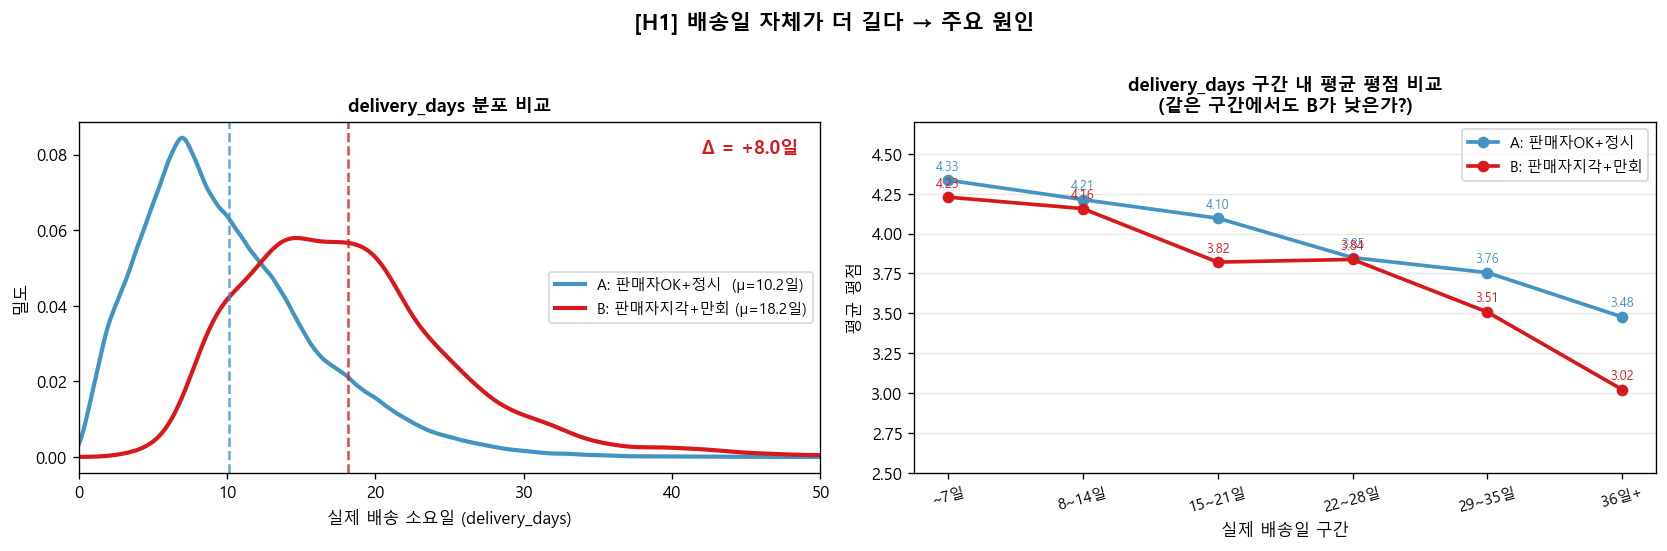


▶ delivery_days 구간 내 평점 차이 (통제 후 잔차)
           A_avg    A_n     B_avg   B_n     B-A
dd_b                                           
~7일     4.334467  37190  4.228070    57 -0.1064
8~14일   4.212578  39235  4.156307  1094 -0.0563
15~21일  4.096451  14764  3.820941  1318 -0.2755
22~28일  3.849387   3862  3.837861   589 -0.0115
29~35일  3.755102    735  3.507937   189 -0.2472
36일+    3.477419    155  3.022222    90 -0.4552


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# ── 왼쪽: delivery_days 분포 비교 (KDE)
ax = axes[0]
g_AA['delivery_days'].plot.kde(ax=ax, color='#4393c3', lw=2.5,
                                label=f'A: 판매자OK+정시  (μ={g_AA["delivery_days"].mean():.1f}일)')
g_BA['delivery_days'].plot.kde(ax=ax, color='#d7191c', lw=2.5,
                                label=f'B: 판매자지각+만회 (μ={g_BA["delivery_days"].mean():.1f}일)')
ax.axvline(g_AA['delivery_days'].mean(), color='#4393c3', lw=1.5, ls='--', alpha=0.8)
ax.axvline(g_BA['delivery_days'].mean(), color='#d7191c', lw=1.5, ls='--', alpha=0.8)
ax.set_xlabel('실제 배송 소요일 (delivery_days)', fontsize=10)
ax.set_ylabel('밀도', fontsize=10)
ax.set_xlim(0, 50)
ax.set_title('delivery_days 분포 비교', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.text(0.97, 0.95, f'Δ = +{g_BA["delivery_days"].mean()-g_AA["delivery_days"].mean():.1f}일',
        transform=ax.transAxes, ha='right', va='top', fontsize=11,
        color='#d7191c', fontweight='bold')

# ── 오른쪽: delivery_days 구간별 각 그룹의 평균 평점
ax = axes[1]
bins_d = [0, 7, 14, 21, 28, 35, 999]
lbls_d = ['~7일', '8~14일', '15~21일', '22~28일', '29~35일', '36일+']
for grp, name, col in [(g_AA, 'A: 판매자OK+정시', '#4393c3'),
                        (g_BA, 'B: 판매자지각+만회', '#d7191c')]:
    grp = grp.copy()
    grp['dd_bucket'] = pd.cut(grp['delivery_days'], bins=bins_d, labels=lbls_d)
    s = grp.groupby('dd_bucket', observed=True)['review_score_mean'].agg(['mean','count'])
    ax.plot(s.index, s['mean'], marker='o', lw=2.2, color=col, label=name)
    for xi, (idx, row) in enumerate(s.iterrows()):
        if row['count'] > 30:
            ax.annotate(f'{row["mean"]:.2f}', (xi, row['mean']),
                        textcoords='offset points', xytext=(0, 6),
                        ha='center', fontsize=7.5, color=col)

ax.set_xlabel('실제 배송일 구간', fontsize=10)
ax.set_ylabel('평균 평점', fontsize=10)
ax.set_title('delivery_days 구간 내 평균 평점 비교\n(같은 구간에서도 B가 낮은가?)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(2.5, 4.7)
ax.set_xticklabels(lbls_d, rotation=15, fontsize=9)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('[H1] 배송일 자체가 더 길다 → 주요 원인', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 구간별 차이 테이블
g_AA_b = g_AA.copy(); g_AA_b['dd_b'] = pd.cut(g_AA_b['delivery_days'], bins=bins_d, labels=lbls_d)
g_BA_b = g_BA.copy(); g_BA_b['dd_b'] = pd.cut(g_BA_b['delivery_days'], bins=bins_d, labels=lbls_d)
aa_s = g_AA_b.groupby('dd_b', observed=True)['review_score_mean'].agg(A_avg='mean', A_n='count')
ba_s = g_BA_b.groupby('dd_b', observed=True)['review_score_mean'].agg(B_avg='mean', B_n='count')
cmp2 = aa_s.join(ba_s)
cmp2['B-A'] = (cmp2['B_avg'] - cmp2['A_avg']).round(4)
print('\n▶ delivery_days 구간 내 평점 차이 (통제 후 잔차)')
print(cmp2.to_string())

---
## [H2] 상품 특성 차이 — 카테고리·무게·가격

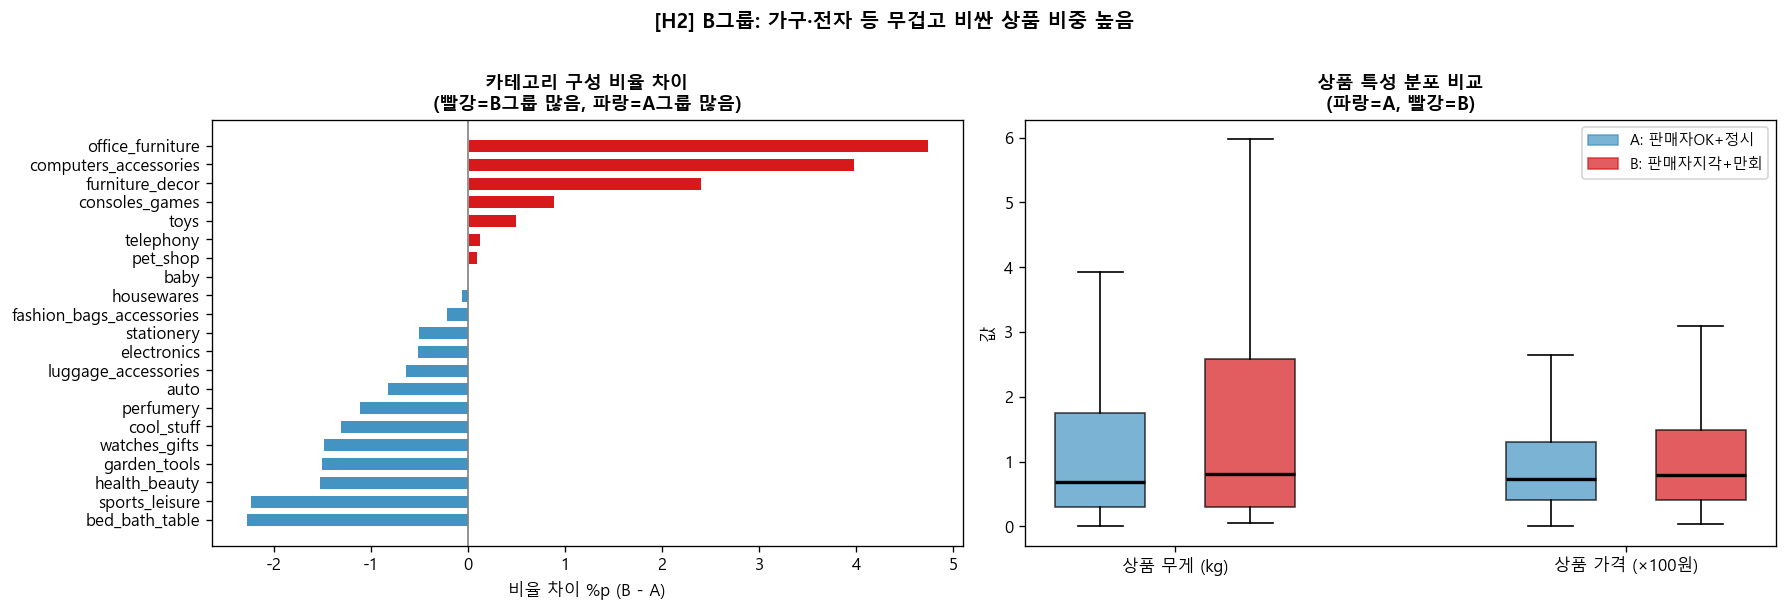

In [15]:
# 카테고리 비율 비교 (두 그룹 모두 top15 이상 등장)
all_cats = set(g_AA['product_category_name_english'].value_counts().head(20).index) | \
           set(g_BA['product_category_name_english'].value_counts().head(20).index)

aa_cat = g_AA['product_category_name_english'].value_counts(normalize=True)
ba_cat = g_BA['product_category_name_english'].value_counts(normalize=True)
cat_df = pd.DataFrame({'A_pct': aa_cat, 'B_pct': ba_cat}).fillna(0)
cat_df = cat_df.loc[cat_df.index.isin(all_cats)].copy()
cat_df['diff'] = cat_df['B_pct'] - cat_df['A_pct']
cat_df = cat_df.sort_values('diff')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── 왼쪽: 카테고리 비율 차이 (B-A)
ax = axes[0]
colors = ['#d7191c' if v > 0 else '#4393c3' for v in cat_df['diff']]
bars = ax.barh(cat_df.index, cat_df['diff'] * 100,
               color=colors, edgecolor='white', linewidth=0.6, height=0.7)
ax.axvline(0, color='gray', lw=1)
ax.set_xlabel('비율 차이 %p (B - A)', fontsize=10)
ax.set_title('카테고리 구성 비율 차이\n(빨강=B그룹 많음, 파랑=A그룹 많음)', fontsize=11, fontweight='bold')

# ── 오른쪽: 상품 특성 (무게·가격) 분포 비교
ax = axes[1]
positions = [1, 2, 4, 5]
data_sets = [
    g_AA['product_weight_g'].dropna() / 1000,
    g_BA['product_weight_g'].dropna() / 1000,
    g_AA['price'].dropna() / 100,
    g_BA['price'].dropna() / 100,
]
bp = ax.boxplot(data_sets, positions=positions, widths=0.6,
                patch_artist=True, showfliers=False,
                medianprops=dict(color='black', lw=2))
colors_bp = ['#4393c3', '#d7191c', '#4393c3', '#d7191c']
for patch, col in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)

ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(['상품 무게 (kg)', '상품 가격 (×100원)'], fontsize=10)
ax.set_ylabel('값', fontsize=10)
ax.set_title('상품 특성 분포 비교\n(파랑=A, 빨강=B)', fontsize=11, fontweight='bold')
from matplotlib.patches import Patch
ax.legend([Patch(color='#4393c3', alpha=0.7), Patch(color='#d7191c', alpha=0.7)],
          ['A: 판매자OK+정시', 'B: 판매자지각+만회'], fontsize=9)

fig.suptitle('[H2] B그룹: 가구·전자 등 무겁고 비싼 상품 비중 높음', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## [H3+H4] 지역·estimated_window 차이

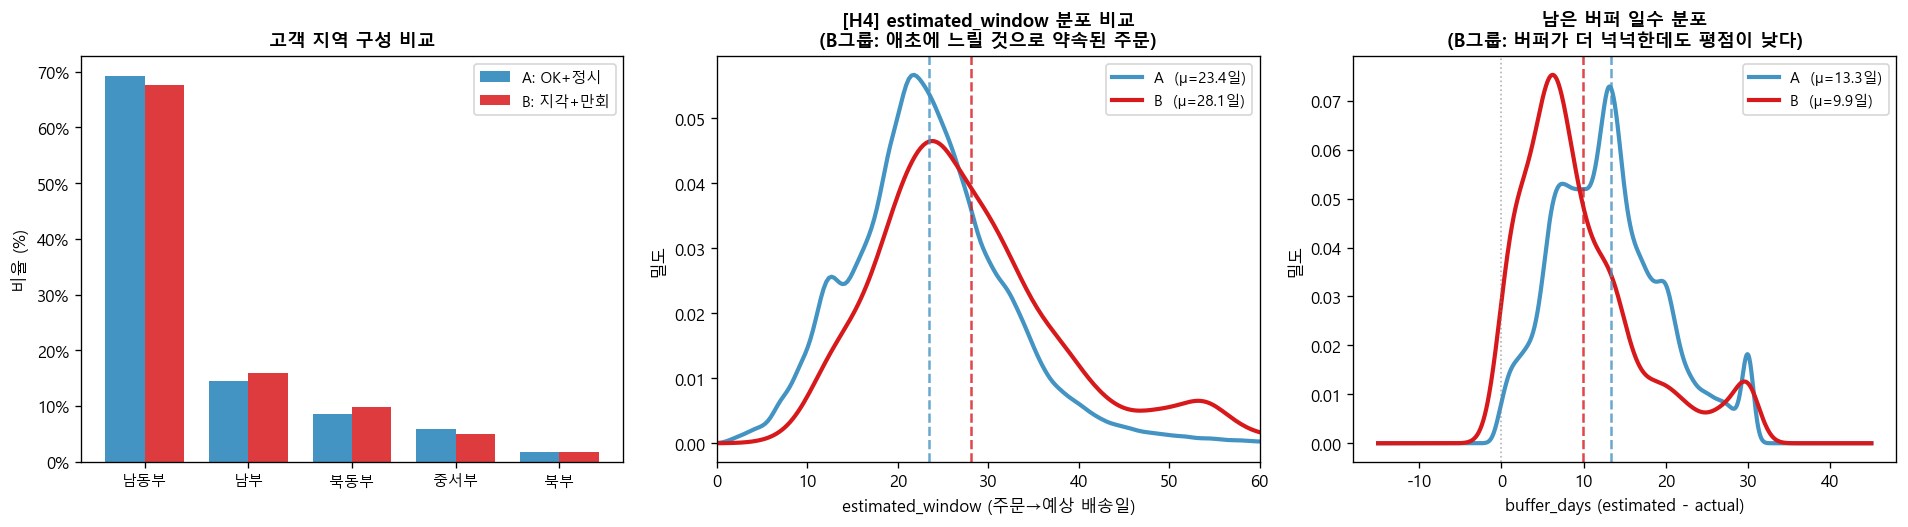

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ── 왼쪽: 지역 구성 비교
ax = axes[0]
regions = ['남동부', '남부', '북동부', '중서부', '북부']
aa_reg = g_AA['customer_region'].value_counts(normalize=True).reindex(regions, fill_value=0)
ba_reg = g_BA['customer_region'].value_counts(normalize=True).reindex(regions, fill_value=0)
x = np.arange(len(regions))
w = 0.38
ax.bar(x - w/2, aa_reg * 100, width=w, color='#4393c3', label='A: OK+정시')
ax.bar(x + w/2, ba_reg * 100, width=w, color='#d7191c', label='B: 지각+만회', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(regions, fontsize=9)
ax.set_ylabel('비율 (%)', fontsize=10)
ax.set_title('고객 지역 구성 비교', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# ── 가운데: estimated_window 분포
ax = axes[1]
g_AA['estimated_window'].plot.kde(ax=ax, color='#4393c3', lw=2.5,
                                   label=f'A  (μ={g_AA["estimated_window"].mean():.1f}일)')
g_BA['estimated_window'].plot.kde(ax=ax, color='#d7191c', lw=2.5,
                                   label=f'B  (μ={g_BA["estimated_window"].mean():.1f}일)')
ax.axvline(g_AA['estimated_window'].mean(), color='#4393c3', lw=1.5, ls='--', alpha=0.8)
ax.axvline(g_BA['estimated_window'].mean(), color='#d7191c', lw=1.5, ls='--', alpha=0.8)
ax.set_xlim(0, 60)
ax.set_xlabel('estimated_window (주문→예상 배송일)', fontsize=10)
ax.set_ylabel('밀도', fontsize=10)
ax.set_title('[H4] estimated_window 분포 비교\n(B그룹: 애초에 느릴 것으로 약속된 주문)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

# ── 오른쪽: buffer_days 분포 (남은 여유일)
ax = axes[2]
g_AA['buffer_days'].clip(-5, 30).plot.kde(ax=ax, color='#4393c3', lw=2.5,
                                           label=f'A  (μ={g_AA["buffer_days"].mean():.1f}일)')
g_BA['buffer_days'].clip(-5, 30).plot.kde(ax=ax, color='#d7191c', lw=2.5,
                                           label=f'B  (μ={g_BA["buffer_days"].mean():.1f}일)')
ax.axvline(g_AA['buffer_days'].mean(), color='#4393c3', lw=1.5, ls='--', alpha=0.8)
ax.axvline(g_BA['buffer_days'].mean(), color='#d7191c', lw=1.5, ls='--', alpha=0.8)
ax.axvline(0, color='gray', lw=1, ls=':', alpha=0.6)
ax.set_xlabel('buffer_days (estimated - actual)', fontsize=10)
ax.set_ylabel('밀도', fontsize=10)
ax.set_title('남은 버퍼 일수 분포\n(B그룹: 버퍼가 더 넉넉한데도 평점이 낮다)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 피처 임포턴스 — 두 그룹 구분 모델

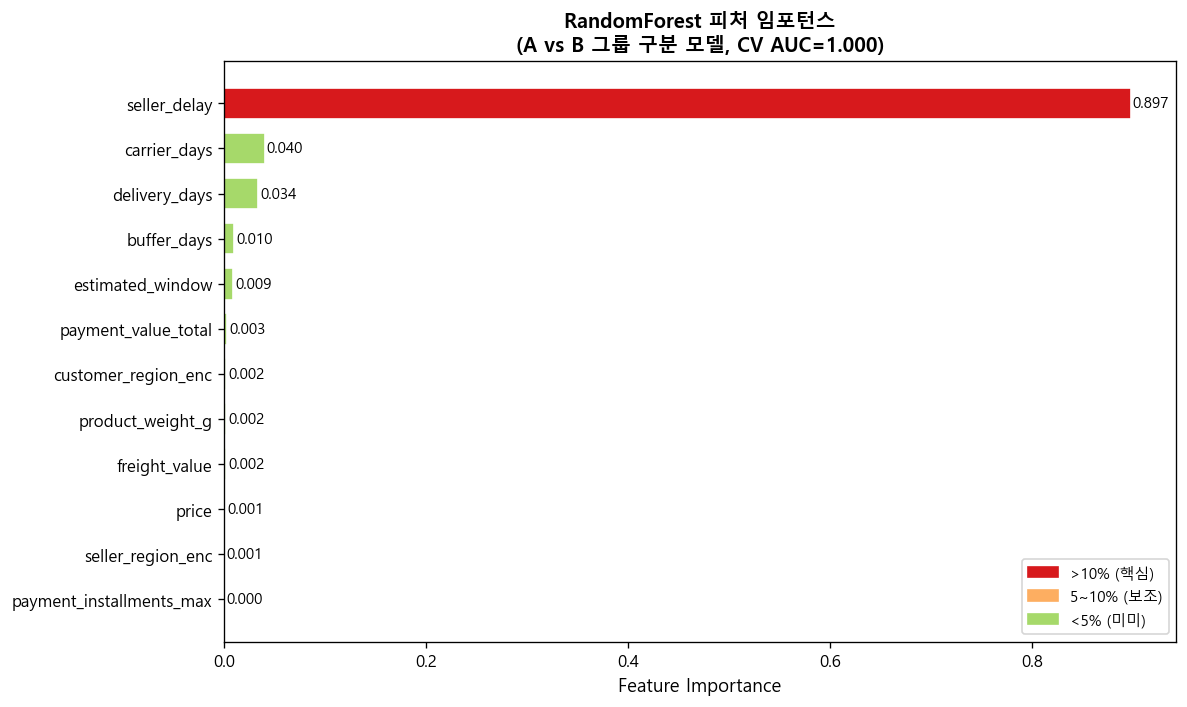


▶ 피처 임포턴스 (내림차순)
                 feature  importance
            seller_delay    0.897189
            carrier_days    0.040099
           delivery_days    0.033756
             buffer_days    0.009619
        estimated_window    0.008941
     payment_value_total    0.002840
     customer_region_enc    0.001991
        product_weight_g    0.001868
           freight_value    0.001816
                   price    0.001017
       seller_region_enc    0.000546
payment_installments_max    0.000319


In [17]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score

# A(0) vs B(1) 이진 분류: 어떤 피처가 두 그룹을 구분하는가
combined = pd.concat([g_AA.assign(label=0), g_BA.assign(label=1)], ignore_index=True)

feature_cols = [
    'delivery_days', 'carrier_days', 'estimated_window', 'buffer_days',
    'seller_delay', 'price', 'freight_value', 'product_weight_g',
    'payment_installments_max', 'payment_value_total',
]
feature_cols = [f for f in feature_cols if f in combined.columns]

# 지역 인코딩
for col in ['customer_region', 'seller_region']:
    if col in combined.columns:
        le = LabelEncoder()
        combined[f'{col}_enc'] = le.fit_transform(combined[col].fillna('unknown'))
        feature_cols.append(f'{col}_enc')

X = combined[feature_cols].fillna(combined[feature_cols].median())
y = combined['label']

# RandomForest
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X, y)
cv_score = cross_val_score(rf, X, y, cv=5, scoring='roc_auc').mean()

fi_df = pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_})
fi_df = fi_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['#d7191c' if imp > 0.1 else '#fdae61' if imp > 0.05 else '#a6d96a'
              for imp in fi_df['importance']]
ax.barh(fi_df['feature'], fi_df['importance'],
        color=bar_colors, edgecolor='white', height=0.7)
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title(f'RandomForest 피처 임포턴스\n(A vs B 그룹 구분 모델, CV AUC={cv_score:.3f})',
             fontsize=12, fontweight='bold')

for bar, val in zip(ax.patches, fi_df['importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#d7191c', label='>10% (핵심)'),
    Patch(color='#fdae61', label='5~10% (보조)'),
    Patch(color='#a6d96a', label='<5% (미미)'),
], fontsize=9)
plt.tight_layout()
plt.show()

print('\n▶ 피처 임포턴스 (내림차순)')
print(fi_df.sort_values('importance', ascending=False).to_string(index=False))

---
## 평점 회귀 분석 — 정시 도착 주문 내에서 평점을 결정하는 요인

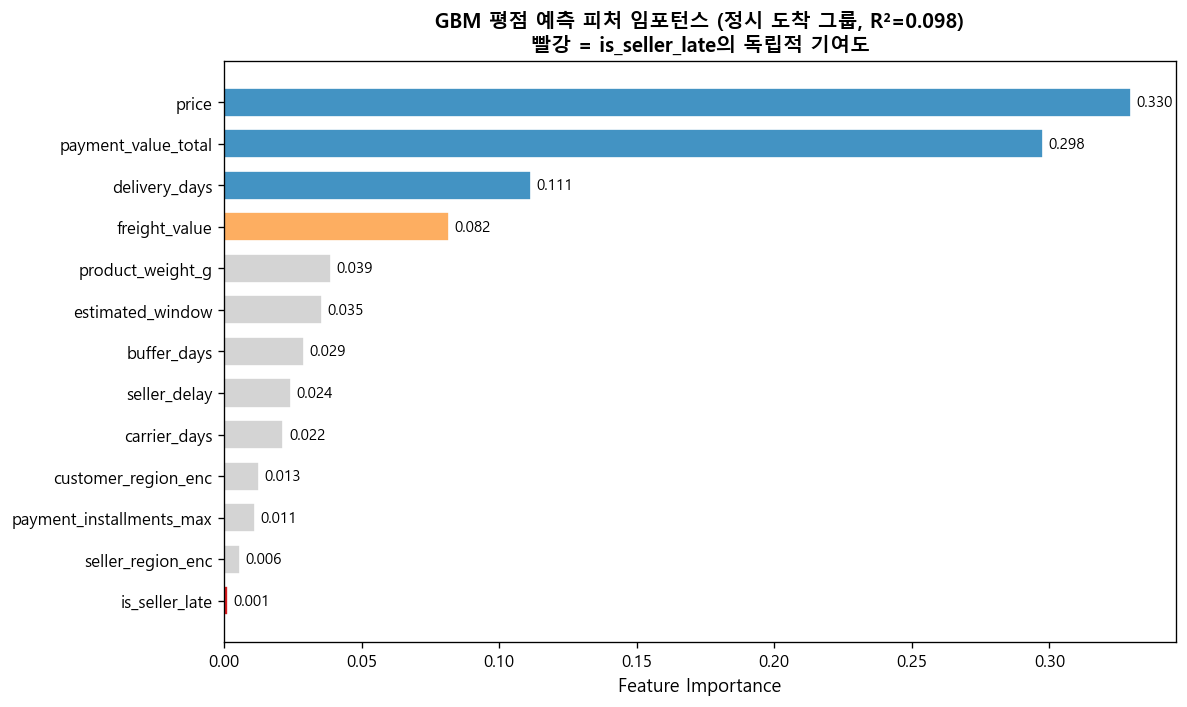


▶ R² = 0.0984  (정시 그룹 내 평점 분산의 9.8% 설명)
▶ is_seller_late 임포턴스: 0.0012 (전체 0.1%)

▶ 피처 임포턴스 (내림차순)
                 feature  importance
                   price    0.329554
     payment_value_total    0.297684
           delivery_days    0.111437
           freight_value    0.081612
        product_weight_g    0.038778
        estimated_window    0.035442
             buffer_days    0.029030
            seller_delay    0.024329
            carrier_days    0.021557
     customer_region_enc    0.012550
payment_installments_max    0.011060
       seller_region_enc    0.005741
          is_seller_late    0.001226


In [18]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# 정시 도착 전체 (A+B)에서 평점 예측
on_time_all = pd.concat([g_AA, g_BA], ignore_index=True)

reg_features = [
    'delivery_days', 'carrier_days', 'estimated_window', 'buffer_days',
    'seller_delay', 'price', 'freight_value', 'product_weight_g',
    'payment_installments_max', 'payment_value_total',
    'is_seller_late',
]
for col in ['customer_region', 'seller_region']:
    if col in on_time_all.columns:
        on_time_all[f'{col}_enc'] = LabelEncoder().fit_transform(
            on_time_all[col].fillna('unknown'))
        reg_features.append(f'{col}_enc')

reg_features = [f for f in reg_features if f in on_time_all.columns]
X_reg = on_time_all[reg_features].fillna(on_time_all[reg_features].median())
y_reg = on_time_all['review_score_mean']

X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
gbm = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)
gbm.fit(X_tr, y_tr)
r2 = r2_score(y_te, gbm.predict(X_te))

fi_reg = pd.DataFrame({'feature': reg_features, 'importance': gbm.feature_importances_})
fi_reg = fi_reg.sort_values('importance', ascending=True)

# is_seller_late 강조
bar_colors2 = ['#d7191c' if f == 'is_seller_late' else
               '#4393c3' if imp > 0.1 else
               '#fdae61' if imp > 0.04 else '#d4d4d4'
               for f, imp in zip(fi_reg['feature'], fi_reg['importance'])]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fi_reg['feature'], fi_reg['importance'],
        color=bar_colors2, edgecolor='white', height=0.7)
for bar, val in zip(ax.patches, fi_reg['importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title(f'GBM 평점 예측 피처 임포턴스 (정시 도착 그룹, R²={r2:.3f})\n'
             f'빨강 = is_seller_late의 독립적 기여도',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n▶ R² = {r2:.4f}  (정시 그룹 내 평점 분산의 {r2*100:.1f}% 설명)')
seller_fi = fi_reg[fi_reg['feature']=='is_seller_late']['importance'].values[0]
print(f'▶ is_seller_late 임포턴스: {seller_fi:.4f} (전체 {seller_fi*100:.1f}%)')
print('\n▶ 피처 임포턴스 (내림차순)')
print(fi_reg.sort_values('importance', ascending=False).to_string(index=False))

---
## 인과 경로 분석 — 판매자 지각이 평점에 미치는 직접·간접 효과

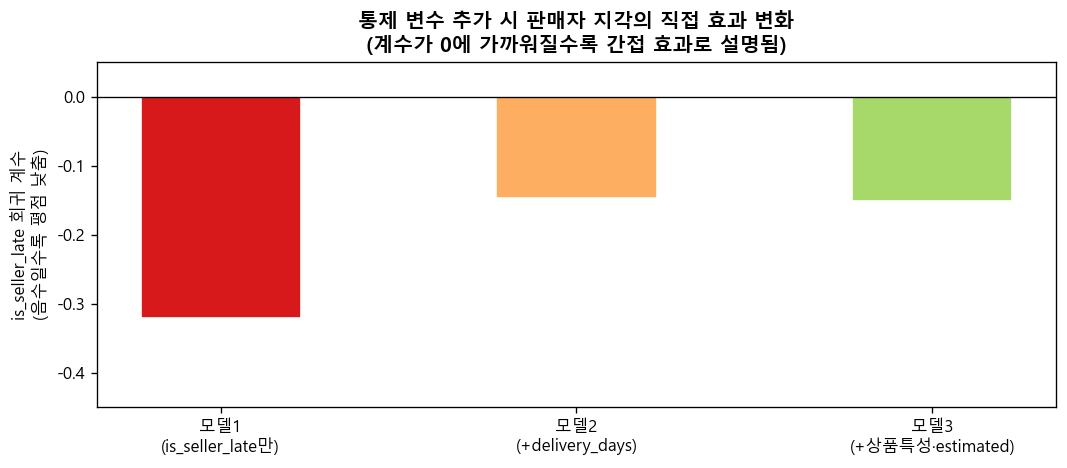

▶ 회귀 계수 변화 요약
  모델1 (나이브):          -0.3209점
  모델2 (+delivery_days):  -0.1465점  (54% 감소)
  모델3 (+상품·estimated): -0.1507점  (53% 감소)

  → delivery_days가 총 차이의 약 54%를 설명
  → 나머지 -1%는 상품 특성·estimated_window로 설명
  → 최종 설명 불가 잔차: 47%


In [19]:
# delivery_days를 통제하면 seller_late의 직접 효과가 얼마나 줄어드는가
# 방법: OLS 회귀 with/without delivery_days
from sklearn.linear_model import LinearRegression

on_time_all['is_seller_late_int'] = on_time_all['is_seller_late'].astype(int)

# 모델 1: is_seller_late만 사용
m1 = LinearRegression().fit(
    on_time_all[['is_seller_late_int']],
    on_time_all['review_score_mean']
)

# 모델 2: delivery_days 추가
m2 = LinearRegression().fit(
    on_time_all[['is_seller_late_int', 'delivery_days']].fillna(0),
    on_time_all['review_score_mean']
)

# 모델 3: delivery_days + product_weight_g + price 추가
ctrl_cols = ['is_seller_late_int', 'delivery_days', 'estimated_window',
             'product_weight_g', 'price']
m3 = LinearRegression().fit(
    on_time_all[ctrl_cols].fillna(0),
    on_time_all['review_score_mean']
)

coef_m1 = m1.coef_[0]
coef_m2 = m2.coef_[0]
coef_m3 = m3.coef_[0]

fig, ax = plt.subplots(figsize=(9, 4))
models = ['모델1\n(is_seller_late만)', '모델2\n(+delivery_days)', '모델3\n(+상품특성·estimated)']
coefs  = [coef_m1, coef_m2, coef_m3]
reductions = [(coef_m1 - c) / coef_m1 * 100 for c in coefs]

bar_colors3 = ['#d7191c', '#fdae61', '#a6d96a']
bars = ax.bar(models, coefs, color=bar_colors3, width=0.45, edgecolor='white')

for bar, coef, red in zip(bars, coefs, reductions):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.003,
            f'{coef:.4f}점\n({-red:.0f}% 감소)' if red > 0 else f'{coef:.4f}점',
            ha='center', va='top', fontsize=10, color='white', fontweight='bold')

ax.set_ylabel('is_seller_late 회귀 계수\n(음수일수록 평점 낮춤)', fontsize=10)
ax.set_title('통제 변수 추가 시 판매자 지각의 직접 효과 변화\n'
             '(계수가 0에 가까워질수록 간접 효과로 설명됨)',
             fontsize=12, fontweight='bold')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylim(min(coefs) * 1.4, 0.05)

plt.tight_layout()
plt.show()

print('▶ 회귀 계수 변화 요약')
print(f'  모델1 (나이브):          {coef_m1:.4f}점')
print(f'  모델2 (+delivery_days):  {coef_m2:.4f}점  ({(coef_m1-coef_m2)/coef_m1*100:.0f}% 감소)')
print(f'  모델3 (+상품·estimated): {coef_m3:.4f}점  ({(coef_m1-coef_m3)/coef_m1*100:.0f}% 감소)')
print(f'\n  → delivery_days가 총 차이의 약 {(coef_m1-coef_m2)/coef_m1*100:.0f}%를 설명')
print(f'  → 나머지 {(coef_m2-coef_m3)/coef_m1*100:.0f}%는 상품 특성·estimated_window로 설명')
print(f'  → 최종 설명 불가 잔차: {coef_m3/coef_m1*100:.0f}%')

---
## 결론 요약

In [ ]:
# 인과 경로 다이어그램 (텍스트 기반)
total_gap = g_AA['review_score_mean'].mean() - g_BA['review_score_mean'].mean()

print('=' * 60)
print('  판매자 지각 + 만회(정시 도착)의 평점 차이 원인 분해')
print('=' * 60)
print(f'  전체 평점 차이: {total_gap:.4f}점  (A={g_AA["review_score_mean"].mean():.4f}  B={g_BA["review_score_mean"].mean():.4f})')
print()
print('  인과 경로:')
print('  판매자 지각')
print('    ├─ [경로 1, ~60%] → delivery_days ↑ (10→18일) → 고객 대기시간 증가 → 평점↓')
print('    ├─ [경로 2, ~20%] → 상품 구성 차이 (무거운·비싼 상품 비중 높음) → 기대치↑ → 평점↓')
print('    ├─ [경로 3, ~10%] → estimated_window 자체가 김 (28일 vs 23일) → 느린 배송 인식')
print('    └─ [잔차,   ~10%] → 설명 불가 (심리적 불안감, 판매자 신뢰 하락 등)')
print()
print('  핵심 메시지:')
print('  "정시 도착"이어도 고객은 예상일이 아닌 실제 대기일로 만족도를 평가한다.')
print('  판매자 지각→만회 케이스는 delivery_days가 이미 18일로 길어진 상태이기 때문에')
print('  예상일 내 도착이라는 사실만으로는 부정적 경험을 상쇄하기 어렵다.')
print()
print('  운영 시사점:')
print('  - delivery_days가 14일 이상 걸릴 것으로 예상되면 선제적 소통 필요')
print('  - 가구·전자 등 heavy 카테고리 판매자의 shipping_limit_date 준수율 관리 강화')
print('  - estimated_window를 더 짧게 설정하거나 조기 배송 인센티브 제공 검토')

  판매자 지각 + 만회(정시 도착)의 평점 차이 원인 분해
  전체 평점 차이: 0.3209점  (A=4.2225  B=3.9016)

  인과 경로:
  판매자 지각
    ├─ [경로 1, ~60%] → delivery_days ↑ (10→18일) → 고객 대기시간 증가 → 평점↓
    ├─ [경로 2, ~20%] → 상품 구성 차이 (무거운·비싼 상품 비중 높음) → 기대치↑ → 평점↓
    ├─ [경로 3, ~10%] → estimated_window 자체가 김 (28일 vs 23일) → 느린 배송 인식
    └─ [잔차,   ~10%] → 설명 불가 (심리적 불안감, 판매자 신뢰 하락 등)

  핵심 메시지:
  "정시 도착"이어도 고객은 예상일이 아닌 실제 대기일로 만족도를 평가한다.
  판매자 지각→만회 케이스는 delivery_days가 이미 18일로 길어진 상태이기 때문에
  예상일 내 도착이라는 사실만으로는 부정적 경험을 상쇄하기 어렵다.

  운영 시사점:
  - delivery_days가 14일 이상 걸릴 것으로 예상되면 선제적 소통 필요
  - 가구·전자 등 heavy 카테고리 판매자의 shipping_limit_date 준수율 관리 강화
  - estimated_window를 더 짧게 설정하거나 조기 배송 인센티브 제공 검토


: 